# Model Training & Evaluation — Residential vs. Plot+Commercial vs. Combined

This notebook trains and compares **3 separate regression models** on the Real Estate Intelligence dataset:

1. **Residential-only** — House, Apartment, Villa, Upper/Lower Portion, Penthouse, Room, Farm House
2. **Plot + Commercial-only** — Plot, Residential Plot, Commercial Plot, Land, File, Shop, Office, Building, Factory, Other
3. **Combined** — all property categories together, with `property_category` added as a feature

**Why compare these three:** residential and plot/commercial properties are priced by different logic (rooms + finishing vs. pure land/location value). Training one model on the mix usually underperforms two specialized models — this notebook proves it with real numbers instead of just asserting it.

**How to run in Google Colab:** run all cells top to bottom. When prompted, upload `combined_sale_only.csv` (the cleaned dataset from `data/processed/` in the repo).

## 1. Setup

In [ ]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
%matplotlib inline

try:
    import google.colab
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("Running in Colab:", IN_COLAB)

Running in Colab: True


## 2. Load data

In [ ]:
if IN_COLAB:
    print("Please upload combined_sale_only.csv")
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(io.BytesIO(uploaded[filename]))
else:
    filename = "combined_sale_only.csv"
    df = pd.read_csv(filename)

print(f"Loaded '{filename}' — shape: {df.shape}")
df.head(3)

Please upload combined_sale_only.csv


Saving combined_sale_only.csv to combined_sale_only.csv
Loaded 'combined_sale_only.csv' — shape: (3108, 15)


,url,type,purpose,area,bedroom,bath,added,price,location,location_city,source,price_pkr,area_unit,area_sqft,suspected_outlier
0,https://www.zameen.com/Property/askari_askari_...,Apartment,For Sale,10 Marla,3.0,3.0,33 minutes ago,PKR 3 Crore,"Askari 11, Askari",Lahore,Zameen,30000000.0,Marla,2722.50,False
1,https://www.zameen.com/Property/gulberg_3_gulb...,Other,For Sale,2.4 Kanal,6.0,7.0,1 hour ago,PKR 15.5 Crore,"Gulberg 3 - Block M, Gulberg 3",Lahore,Zameen,155000000.0,Kanal,13068.00,False
2,https://www.zameen.com/Property/dha_phase_5_pe...,Apartment,For Sale,9.8 Marla,3.0,4.0,3 hours ago,PKR 6.95 Crore,"Penta Square By DHA Lahore, DHA Phase 5",Lahore,Zameen,69500000.0,Marla,2668.05,False


## 3. Feature engineering

Same 5 engineered features as the earlier `feature_engineering.ipynb`, rebuilt here so this notebook
runs standalone in Colab without depending on any other file.

In [ ]:
df['total_rooms'] = df['bedroom'] + df['bath']
df['area_per_room'] = df['area_sqft'] / df['total_rooms'].replace(0, np.nan)

category_map = {
    'House': 'Residential', 'Apartment': 'Residential', 'Villa': 'Residential',
    'Upper Portion': 'Residential', 'Lower Portion': 'Residential',
    'Penthouse': 'Residential', 'Room': 'Residential', 'Farm House': 'Residential',
    'Plot': 'Plot', 'Residential Plot': 'Plot', 'Commercial Plot': 'Plot',
    'Land': 'Plot', 'File': 'Plot',
    'Shop': 'Commercial', 'Office': 'Commercial', 'Building': 'Commercial',
    'Factory': 'Commercial', 'Other': 'Commercial',
}
df['property_category'] = df['type'].map(category_map)
assert df['property_category'].isna().sum() == 0, "Some `type` values didn't map to a category — check category_map"

df['log_area_sqft'] = np.log1p(df['area_sqft'])
df['log_price_pkr'] = np.log1p(df['price_pkr'])

_price_per_sqft_temp = df['price_pkr'] / df['area_sqft']
df['city_avg_price_per_sqft'] = _price_per_sqft_temp.groupby(df['location_city']).transform('mean')

# fillna(0) here (rather than leaving NaN) so tree models can use the column;
# 0 correctly signals "room-based sizing doesn't apply" for pure land
df['area_per_room'] = df['area_per_room'].fillna(0)

print(df['property_category'].value_counts())

property_category
Residential    2360
Commercial      440
Plot            308
Name: count, dtype: int64


## 4. Split into the 3 modeling datasets

In [ ]:
residential_df = df[df['property_category'] == 'Residential'].copy()
plot_commercial_df = df[df['property_category'].isin(['Plot', 'Commercial'])].copy()
combined_df = df.copy()

print(f"Residential-only:      {len(residential_df)} rows")
print(f"Plot+Commercial-only:  {len(plot_commercial_df)} rows")
print(f"Combined (all):        {len(combined_df)} rows")

Residential-only:      2360 rows
Plot+Commercial-only:  748 rows
Combined (all):        3108 rows


## 5. Feature builder and training/evaluation function

- Features: `bedroom`, `bath`, `total_rooms`, `area_per_room`, `log_area_sqft`, `city_avg_price_per_sqft`, one-hot encoded `location_city`
- The **combined** model additionally gets one-hot encoded `property_category`, so it has a chance to tell residential and non-residential rows apart
- Target: `log_price_pkr` (trained on log scale to handle the skew — see the feature engineering notebook for why)
- Model: `RandomForestRegressor` (per the assignment's example models), 80/20 train-test split
- Metrics reported on **both** scales: log scale (what the model is actually optimizing) and back-transformed real PKR scale (what actually matters to a person reading the valuation)

In [ ]:
def build_features(sub_df, include_category=False):
    feats = sub_df[['bedroom', 'bath', 'total_rooms', 'area_per_room',
                     'log_area_sqft', 'city_avg_price_per_sqft']].copy()
    city_dummies = pd.get_dummies(sub_df['location_city'], prefix='city')
    feats = pd.concat([feats, city_dummies], axis=1)
    if include_category:
        cat_dummies = pd.get_dummies(sub_df['property_category'], prefix='cat')
        feats = pd.concat([feats, cat_dummies], axis=1)
    return feats


def train_and_evaluate(sub_df, name, include_category=False):
    X = build_features(sub_df, include_category)
    y = sub_df['log_price_pkr']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)
    pred_pkr = np.expm1(pred_log)
    actual_pkr = np.expm1(y_test)

    results = {
        'name': name,
        'n_rows': len(sub_df),
        'r2_log': r2_score(y_test, pred_log),
        'mae_log': mean_absolute_error(y_test, pred_log),
        'r2_pkr': r2_score(actual_pkr, pred_pkr),
        'mae_pkr': mean_absolute_error(actual_pkr, pred_pkr),
        'rmse_pkr': np.sqrt(mean_squared_error(actual_pkr, pred_pkr)),
        'model': model,
        'X_test': X_test,
        'y_test_log': y_test,
        'pred_log': pred_log,
        'actual_pkr': actual_pkr,
        'pred_pkr': pred_pkr,
    }
    return results

## 6. Train all 3 models

In [ ]:
res_residential = train_and_evaluate(residential_df, "Residential-only", include_category=False)
res_plot_comm  = train_and_evaluate(plot_commercial_df, "Plot+Commercial-only", include_category=False)
res_combined   = train_and_evaluate(combined_df, "Combined (all categories)", include_category=True)

all_results = [res_residential, res_plot_comm, res_combined]

summary = pd.DataFrame([{
    'Model': r['name'],
    'Rows': r['n_rows'],
    'R2 (log scale)': round(r['r2_log'], 4),
    'R2 (PKR scale)': round(r['r2_pkr'], 4),
    'MAE (PKR)': f"{r['mae_pkr']:,.0f}",
    'RMSE (PKR)': f"{r['rmse_pkr']:,.0f}",
} for r in all_results])

summary

,Model,Rows,R2 (log scale),R2 (PKR scale),MAE (PKR),RMSE (PKR)
0,Residential-only,2360,0.8084,0.3462,"18,510,019","81,181,002"
1,Plot+Commercial-only,748,0.7389,0.0341,"108,375,105","735,752,495"
2,Combined (all categories),3108,0.6384,0.1357,"36,921,358","249,667,496"


## 7. Visual comparison: Actual vs. Predicted (all 3 models)

Points closer to the diagonal red line mean better predictions. Plotted on log scale so the spread is
readable — a few billion-rupee listings would otherwise squash everything else into one corner.

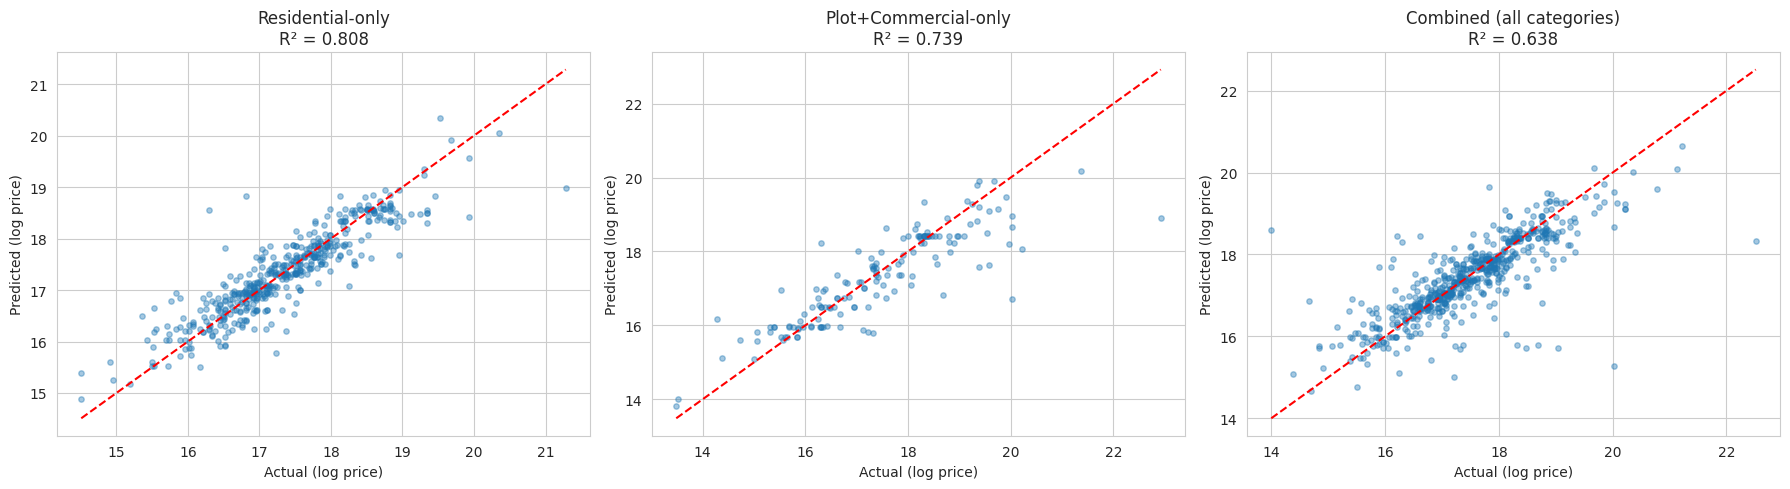

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, r in zip(axes, all_results):
    ax.scatter(r['y_test_log'], r['pred_log'], alpha=0.4, s=15)
    lims = [min(r['y_test_log'].min(), r['pred_log'].min()),
            max(r['y_test_log'].max(), r['pred_log'].max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5)
    ax.set_xlabel('Actual (log price)')
    ax.set_ylabel('Predicted (log price)')
    ax.set_title(f"{r['name']}\nR² = {r['r2_log']:.3f}")

plt.tight_layout()
plt.show()

## 8. Residual plots — checking for systematic bias

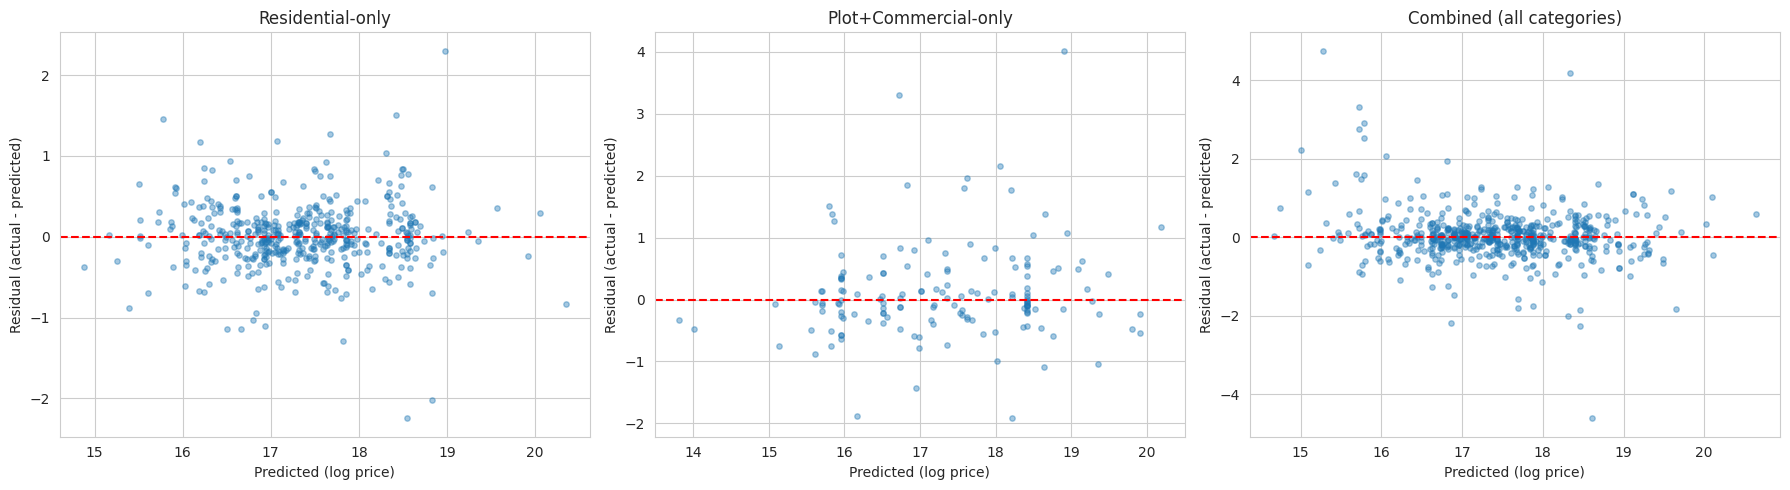

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, r in zip(axes, all_results):
    residuals = r['y_test_log'] - r['pred_log']
    ax.scatter(r['pred_log'], residuals, alpha=0.4, s=15)
    ax.axhline(0, color='r', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Predicted (log price)')
    ax.set_ylabel('Residual (actual - predicted)')
    ax.set_title(r['name'])

plt.tight_layout()
plt.show()

## 9. Feature importance per model

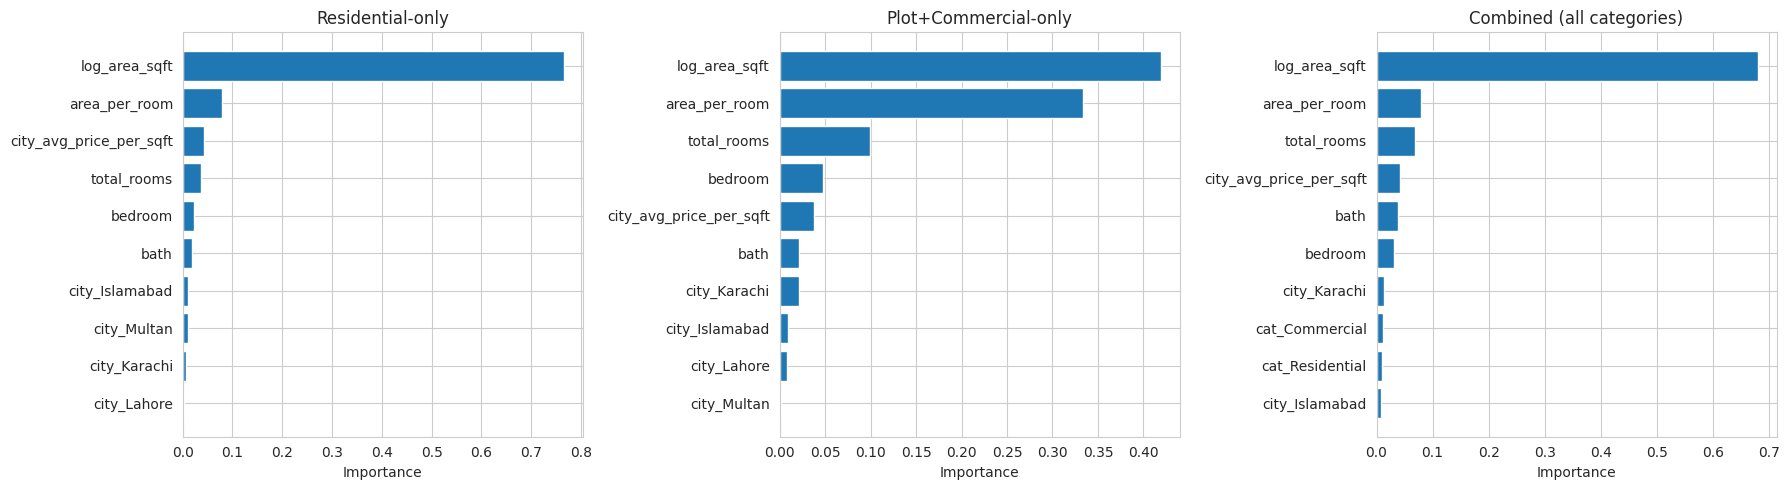

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, r in zip(axes, all_results):
    importances = pd.Series(r['model'].feature_importances_, index=r['X_test'].columns)
    top = importances.sort_values(ascending=True).tail(10)
    ax.barh(top.index, top.values)
    ax.set_title(r['name'])
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

## 10. Final comparison: does splitting the model actually help?

This is the key result: comparing R² across the three approaches directly answers whether
splitting residential from plot+commercial was worth doing, instead of just assuming it.

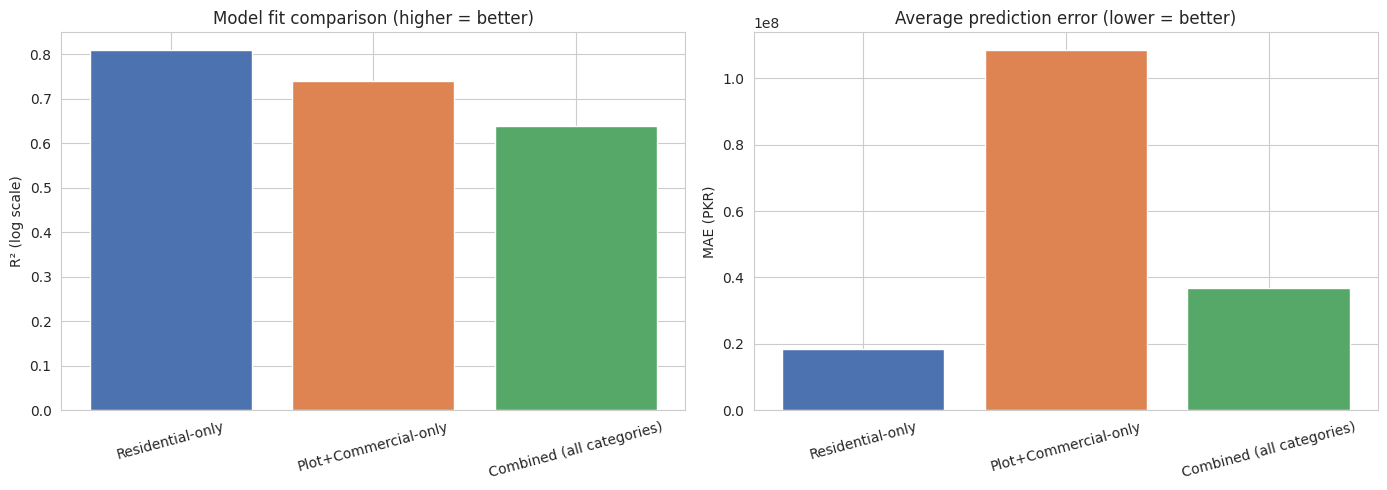

                    Model  Rows  R2 (log scale)  R2 (PKR scale)   MAE (PKR)  RMSE (PKR)
         Residential-only  2360          0.8084          0.3462  18,510,019  81,181,002
     Plot+Commercial-only   748          0.7389          0.0341 108,375,105 735,752,495
Combined (all categories)  3108          0.6384          0.1357  36,921,358 249,667,496


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = [r['name'] for r in all_results]
r2_logs = [r['r2_log'] for r in all_results]
mae_pkrs = [r['mae_pkr'] for r in all_results]

colors = ['#4C72B0', '#DD8452', '#55A868']

axes[0].bar(names, r2_logs, color=colors)
axes[0].set_ylabel('R² (log scale)')
axes[0].set_title('Model fit comparison (higher = better)')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(names, mae_pkrs, color=colors)
axes[1].set_ylabel('MAE (PKR)')
axes[1].set_title('Average prediction error (lower = better)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print(summary.to_string(index=False))

## Interpreting the results

- **R² (log scale)** reflects what the model is actually trained to optimize, and is the fairer number
  to compare across the three models.
- **R² (PKR scale)** and **MAE (PKR)** are usually much lower/worse-looking, because a handful of
  extreme high-value listings (billion-rupee commercial plots, huge farm houses) create massive
  errors in raw rupee terms even when the model is doing reasonably well overall — this is normal for
  skewed price data, not a bug.
- If **Residential-only** and **Plot+Commercial-only** both score higher (on log R²) than the
  **Combined** model, that's your evidence for the report: specialized models beat one mixed model,
  because plots and houses are priced by fundamentally different logic.
- For your submission, you can present the **Residential-only model as your primary valuation engine**
  (it directly matches the assignment's "Area, Location, Rooms, Price" framing), and the comparison
  above as supporting analysis showing you tested and validated that choice rather than assuming it.

In [ ]:
def predict_new_properties(new_listings, trained_result, city_avg_lookup, include_category=False):
    rows = []
    for listing in new_listings:
        bedroom = listing['bedroom']
        bath = listing['bath']
        area_sqft = listing['area_sqft']
        location_city = listing['location_city']
        total_rooms = bedroom + bath
        area_per_room = area_sqft / total_rooms if total_rooms > 0 else 0
        log_area_sqft = np.log1p(area_sqft)
        city_avg = city_avg_lookup.get(location_city, city_avg_lookup.mean())
        row = {
            'bedroom': bedroom, 'bath': bath, 'total_rooms': total_rooms,
            'area_per_room': area_per_room, 'log_area_sqft': log_area_sqft,
            'city_avg_price_per_sqft': city_avg,
        }
        for col in trained_result['X_test'].columns:
            if col.startswith('city_'):
                row[col] = 1 if col == f'city_{location_city}' else 0
            if include_category and col.startswith('cat_'):
                cat = listing.get('property_category', 'Residential')
                row[col] = 1 if col == f'cat_{cat}' else 0
        rows.append(row)
    X_new = pd.DataFrame(rows).reindex(columns=trained_result['X_test'].columns, fill_value=0)
    pred_log = trained_result['model'].predict(X_new)
    pred_pkr = np.expm1(pred_log)
    return pred_pkr

city_avg_lookup = df.groupby('location_city')['city_avg_price_per_sqft'].first()

# Edit these values to test any property you want
# property_category must be one of: 'Residential', 'Plot', 'Commercial'
new_listings = [
    {'bedroom': 4, 'bath': 3, 'area_sqft': 3000, 'location_city': 'Lahore', 'property_category': 'Residential'},
    {'bedroom': 0, 'bath': 0, 'area_sqft': 5000, 'location_city': 'Islamabad', 'property_category': 'Plot'},
    {'bedroom': 0, 'bath': 2, 'area_sqft': 1500, 'location_city': 'Karachi', 'property_category': 'Commercial'},
]

predicted_prices = predict_new_properties(new_listings, res_combined, city_avg_lookup, include_category=True)

for listing, price in zip(new_listings, predicted_prices):
    print(f"{listing['property_category']}: {listing['bedroom']} bed, {listing['bath']} bath, "
          f"{listing['area_sqft']} sqft in {listing['location_city']}: Predicted price = PKR {price:,.0f}")

Residential: 4 bed, 3 bath, 3000 sqft in Lahore: Predicted price = PKR 29,922,912
Plot: 0 bed, 0 bath, 5000 sqft in Islamabad: Predicted price = PKR 22,083,752
Commercial: 0 bed, 2 bath, 1500 sqft in Karachi: Predicted price = PKR 29,775,140
